In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from functions.set_plot_settings import setPlotSettings
setPlotSettings(font=True)

In [2]:
# Function to compute total momentum:
def totalMomentum(df):
    px = df["Px"].to_numpy()
    py = df["Py"].to_numpy()
    pz = df["Pz"].to_numpy()
    ptotal = []
    for i in range(len(px)):
        ptotal.append(np.sqrt(px[i]**2+py[i]**2+pz[i]**2))
    return ptotal

### MAP beam ($\mu^+$)

Provided by Dave and presumably used by Yuri in his HFOFO papers.

In [3]:
# Define input beam file:
file = 'initial.dat'

In [4]:
# Read in data from file:
df = pd.read_csv(file, comment='#', sep=r'\s+', 
                 names=["x", "y", "z", "Px", "Py", "Pz", "t", "PDGid", "EventID", "TrackID", "ParentID", "Weight"])

ptotal = totalMomentum(df)

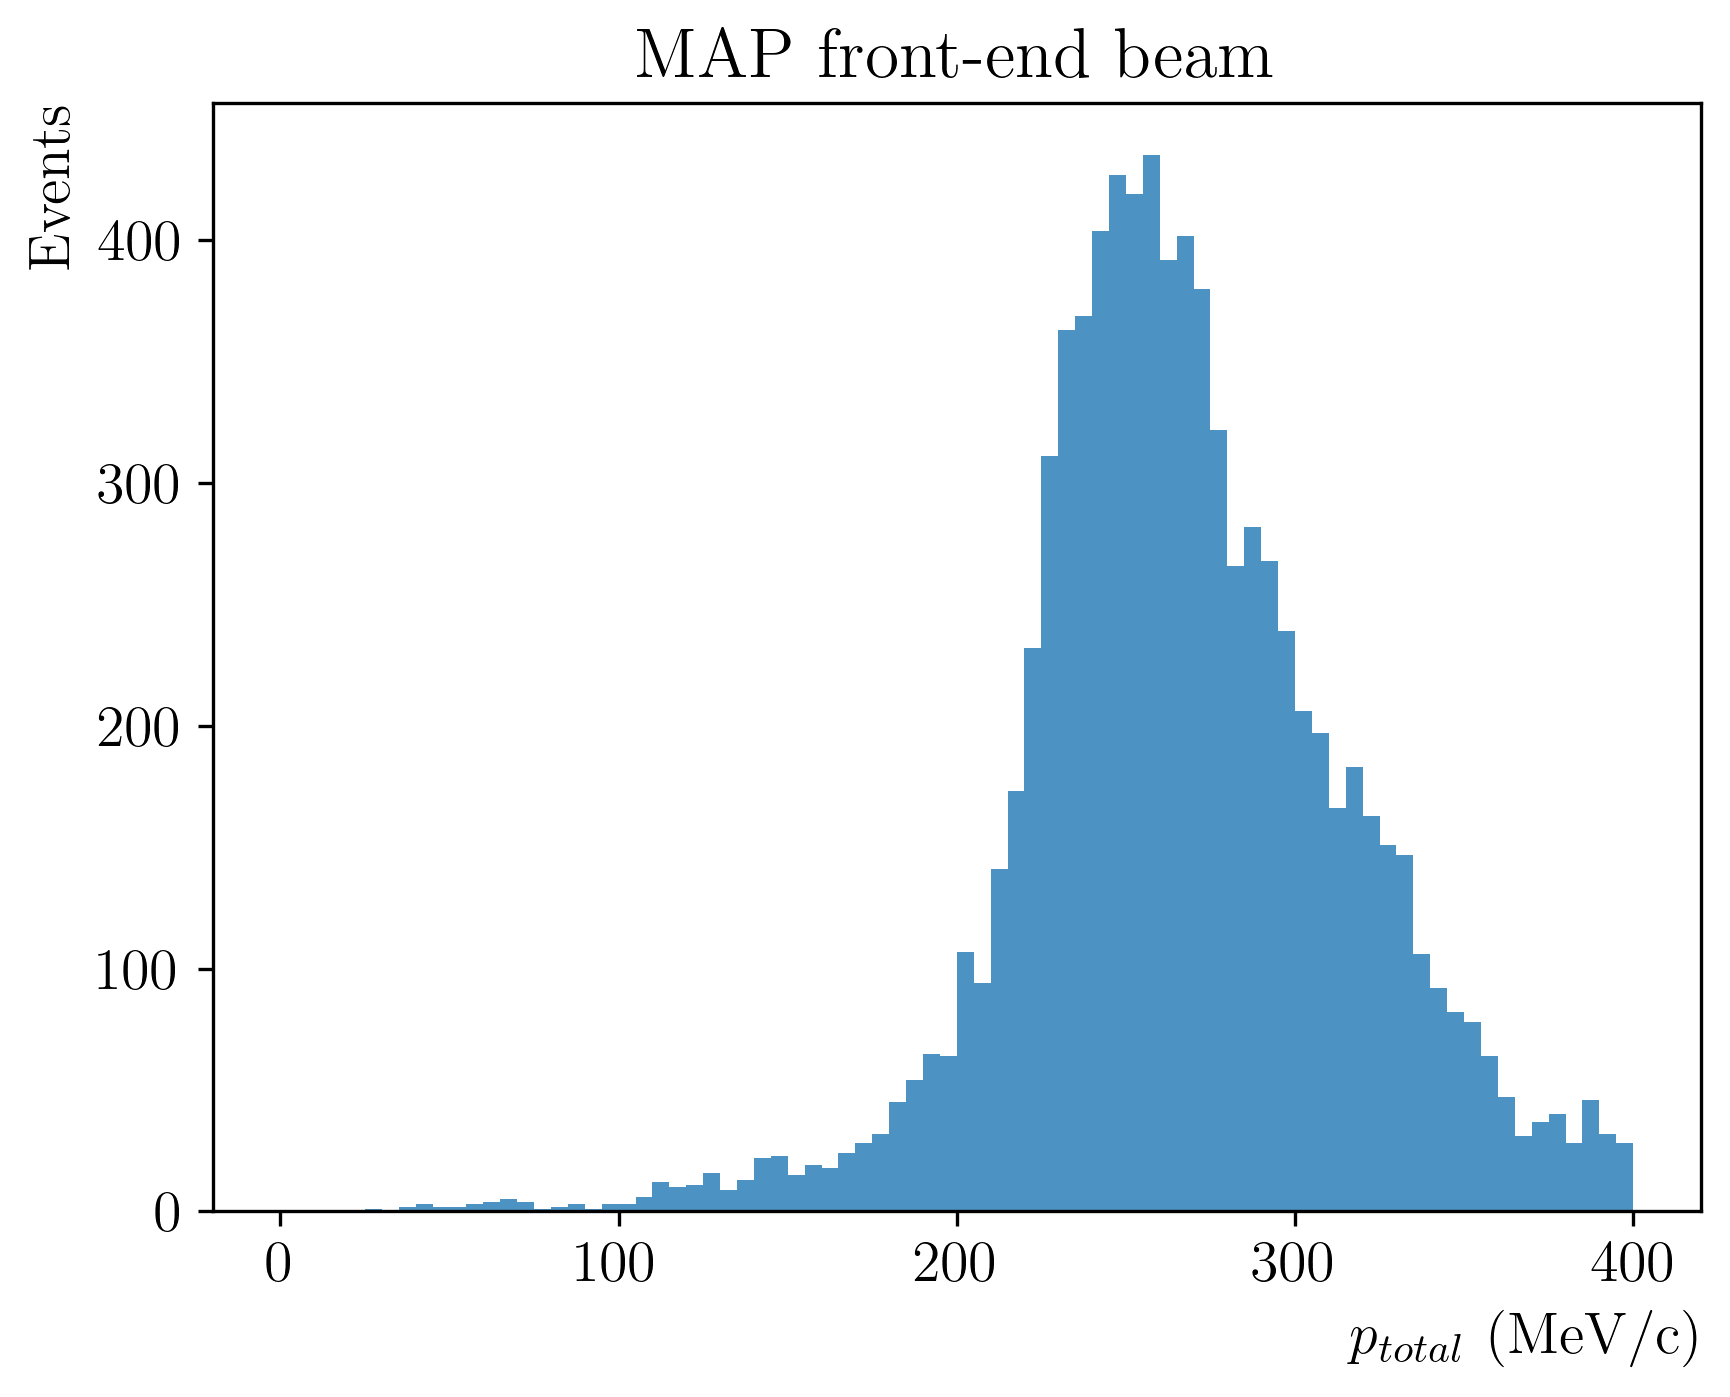

In [5]:
# Plot distribution:
plt.hist(ptotal,bins=80,range=(0,400), alpha=0.8)
plt.xlabel('$p_{total}$ (MeV/c)',loc='right')
plt.ylabel('Events',loc='top')
plt.title('MAP front-end beam')
plt.show()

In [6]:
# Include only mu+:
dfmu = df[df.PDGid == -13]

ptotalmu = totalMomentum(dfmu)

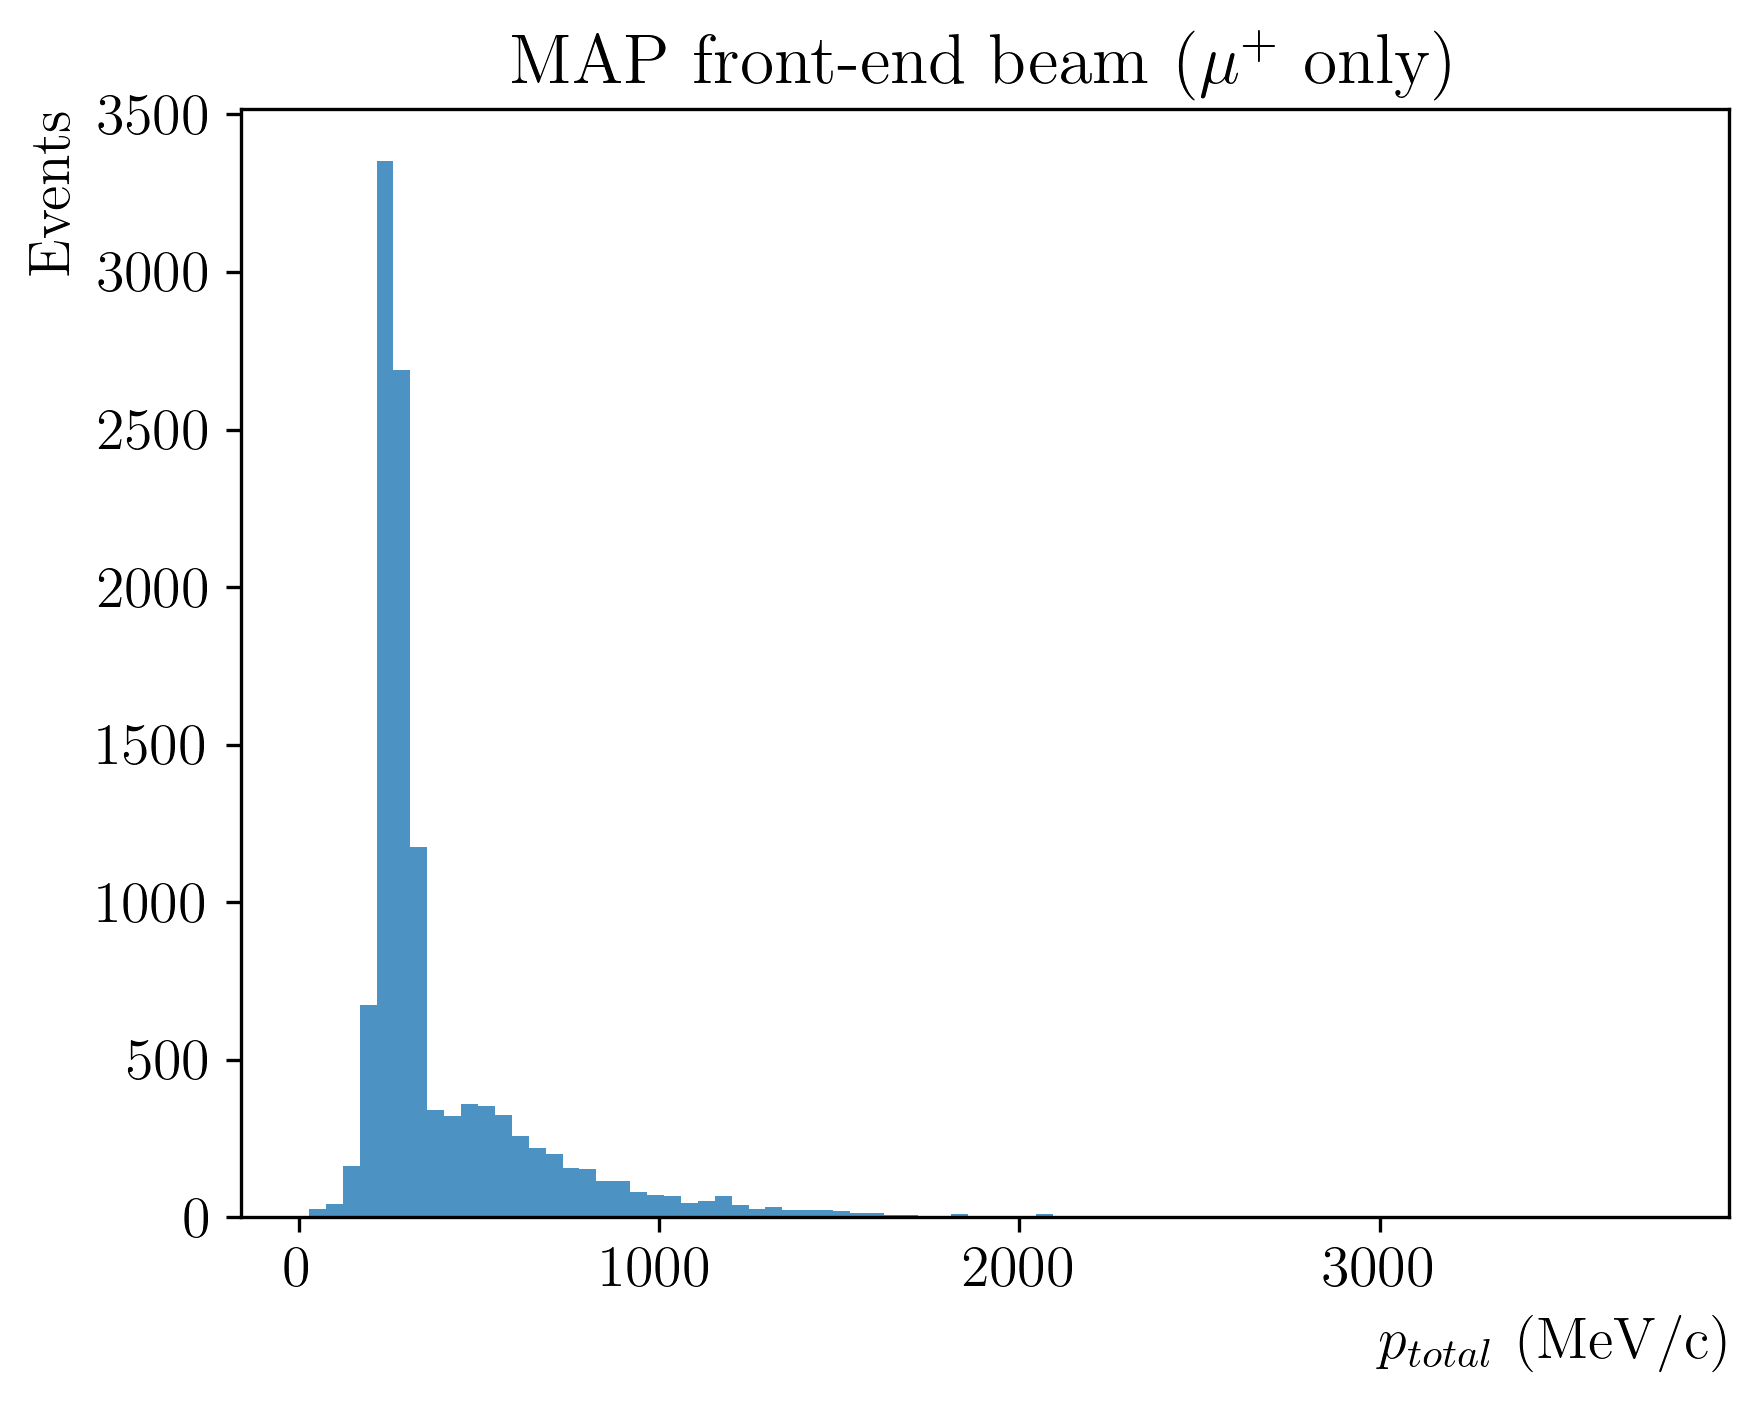

In [7]:
# Plot distribution:
# plt.hist(ptotalmu,bins=80,range=(0,400), color='white', alpha=0.8)
plt.hist(ptotalmu,bins=80, alpha=0.8)
plt.xlabel('$p_{total}$ (MeV/c)',loc='right')
plt.ylabel('Events',loc='top')
plt.title('MAP front-end beam ($\mu^+$ only)')
plt.show()

In [8]:
# Number of mu+:
N = len(dfmu)
print(N)

11755


In [9]:
Ptotals = totalMomentum(dfmu)
np.average(Ptotals)

np.float64(404.14393344753535)

In [10]:
Ptotals_cut = []
for i in range(len(Ptotals)):
    if Ptotals[i] > 150:
        if Ptotals[i] < 350:
            Ptotals_cut.append(Ptotals[i])
np.average(Ptotals_cut)

np.float64(263.63933953792383)

In [11]:
np.std(df['x'].values)

np.float64(81.01108718212367)

In [12]:
np.std(df['y'].values)

np.float64(80.80668533874855)

In [13]:
np.std(df['t'].values)

np.float64(57.49069593037006)

In [14]:
np.std((df['Px']/df['Pz']).values)

np.float64(0.09689645536622128)

In [45]:
timesmu = dfmu['t'].values

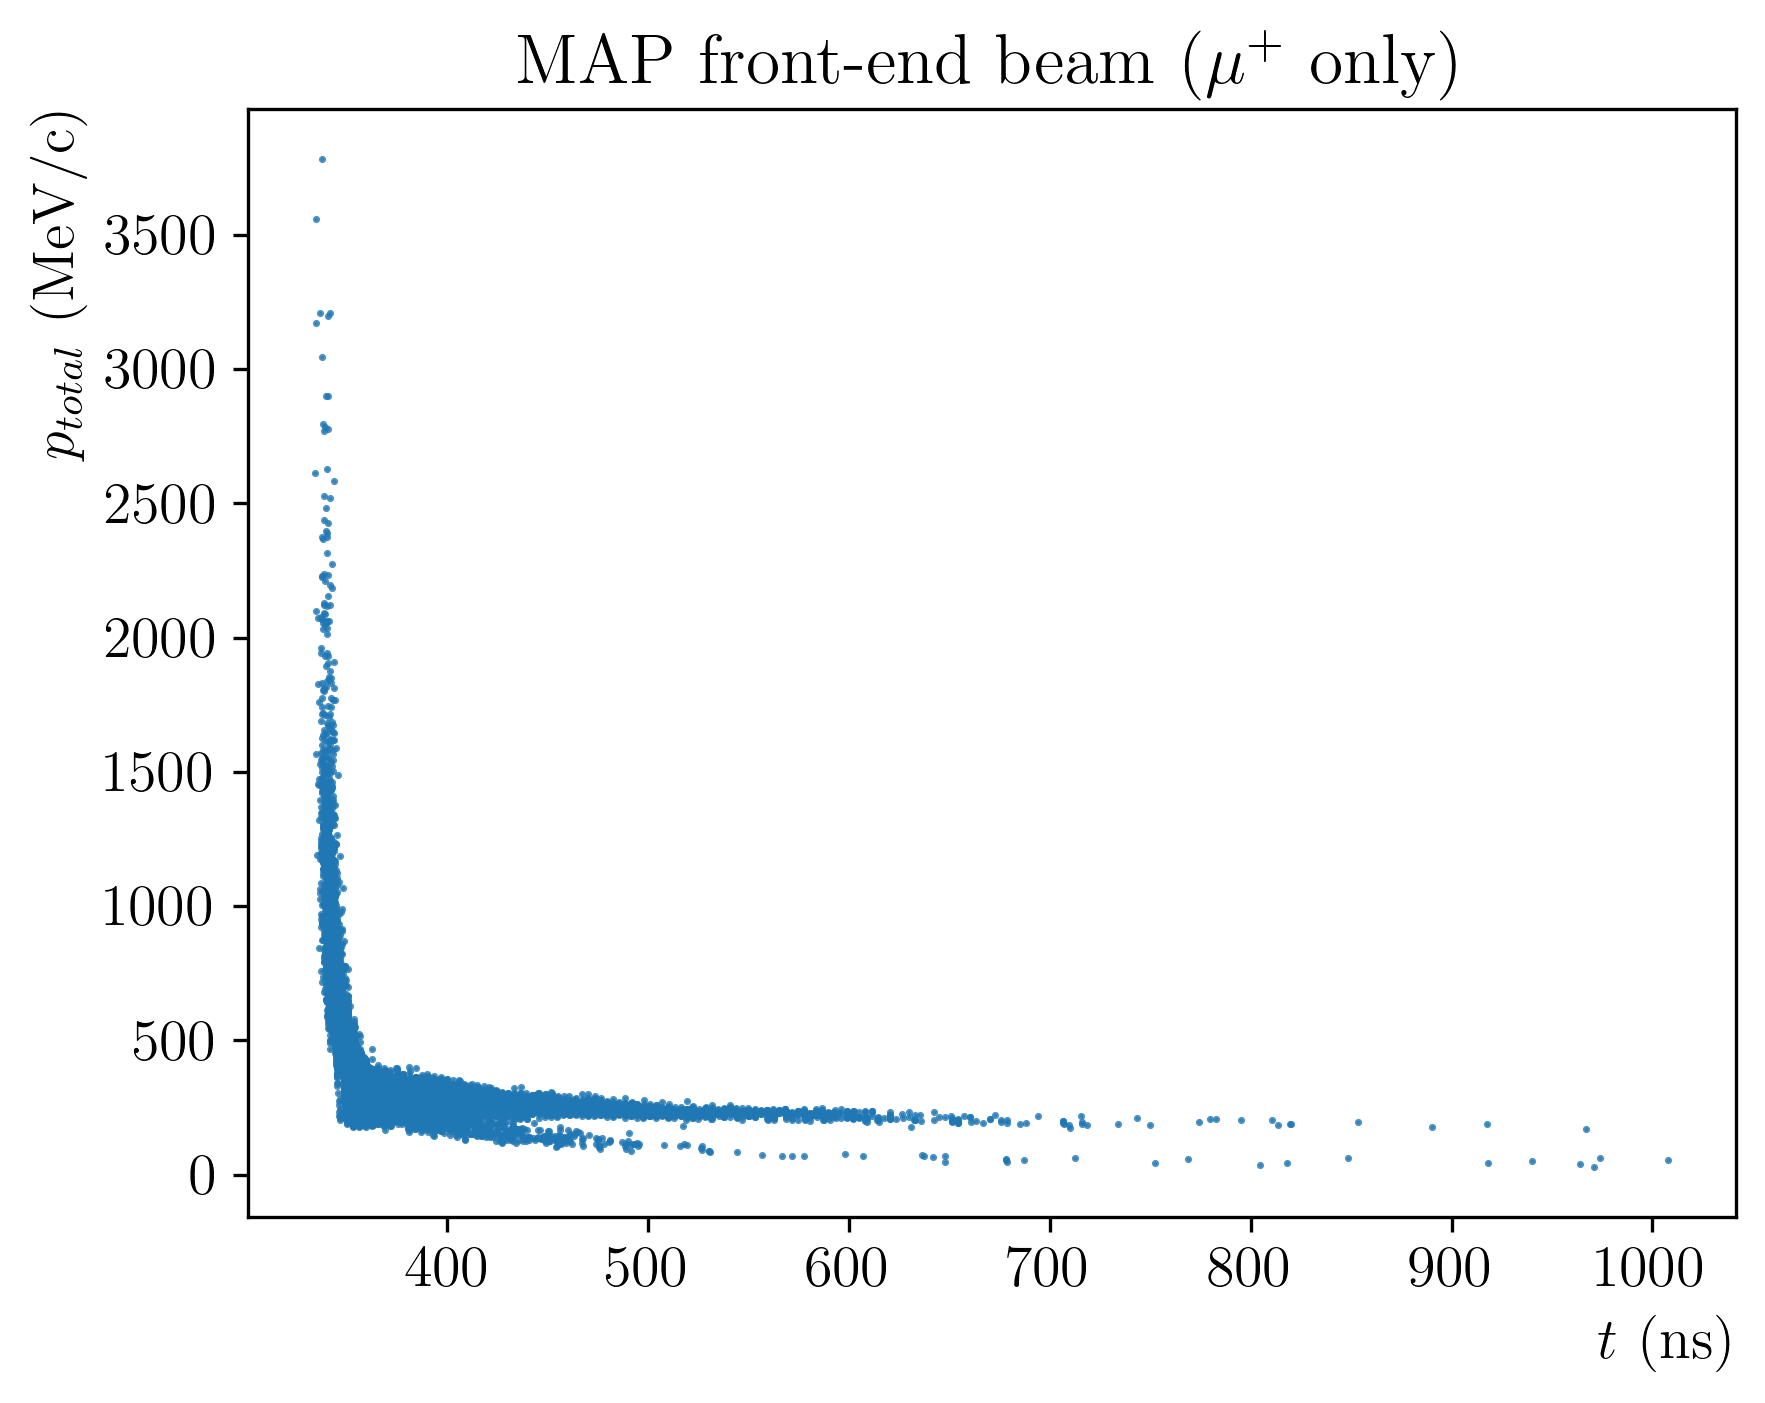

In [49]:
plt.scatter(timesmu, ptotalmu, alpha=0.8, s=0.5)
plt.xlabel('$t$ (ns)',loc='right')
plt.ylabel('$p_{total}$ (MeV/c)',loc='top')
plt.title('MAP front-end beam ($\mu^+$ only)')
plt.show()

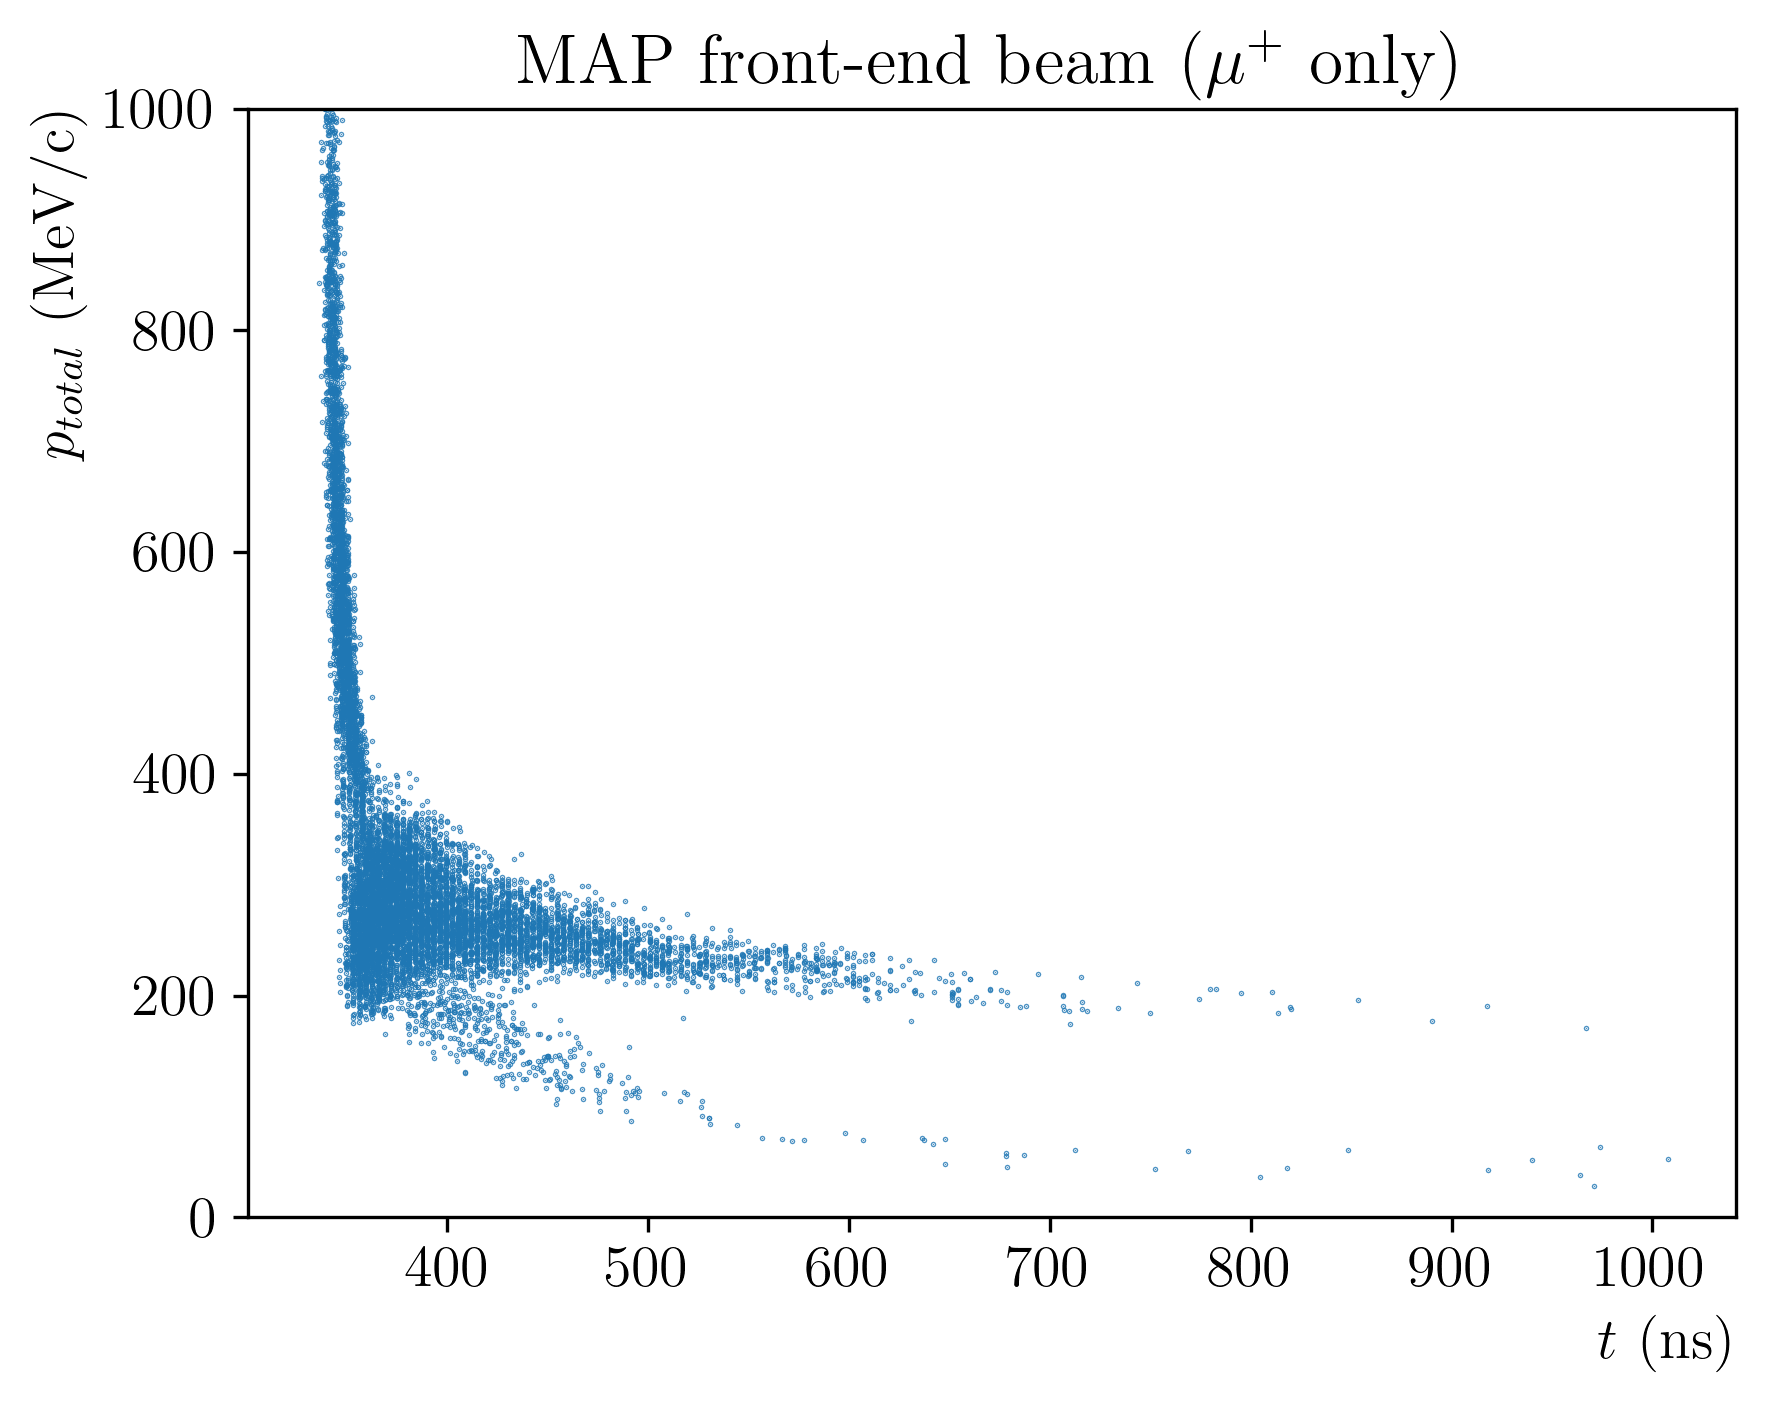

In [67]:
plt.scatter(timesmu, ptotalmu, alpha=0.8, s=0.1)
plt.xlabel('$t$ (ns)',loc='right')
plt.ylabel('$p_{total}$ (MeV/c)',loc='top')
plt.title('MAP front-end beam ($\mu^+$ only)')
plt.ylim(0,1000)
plt.show()

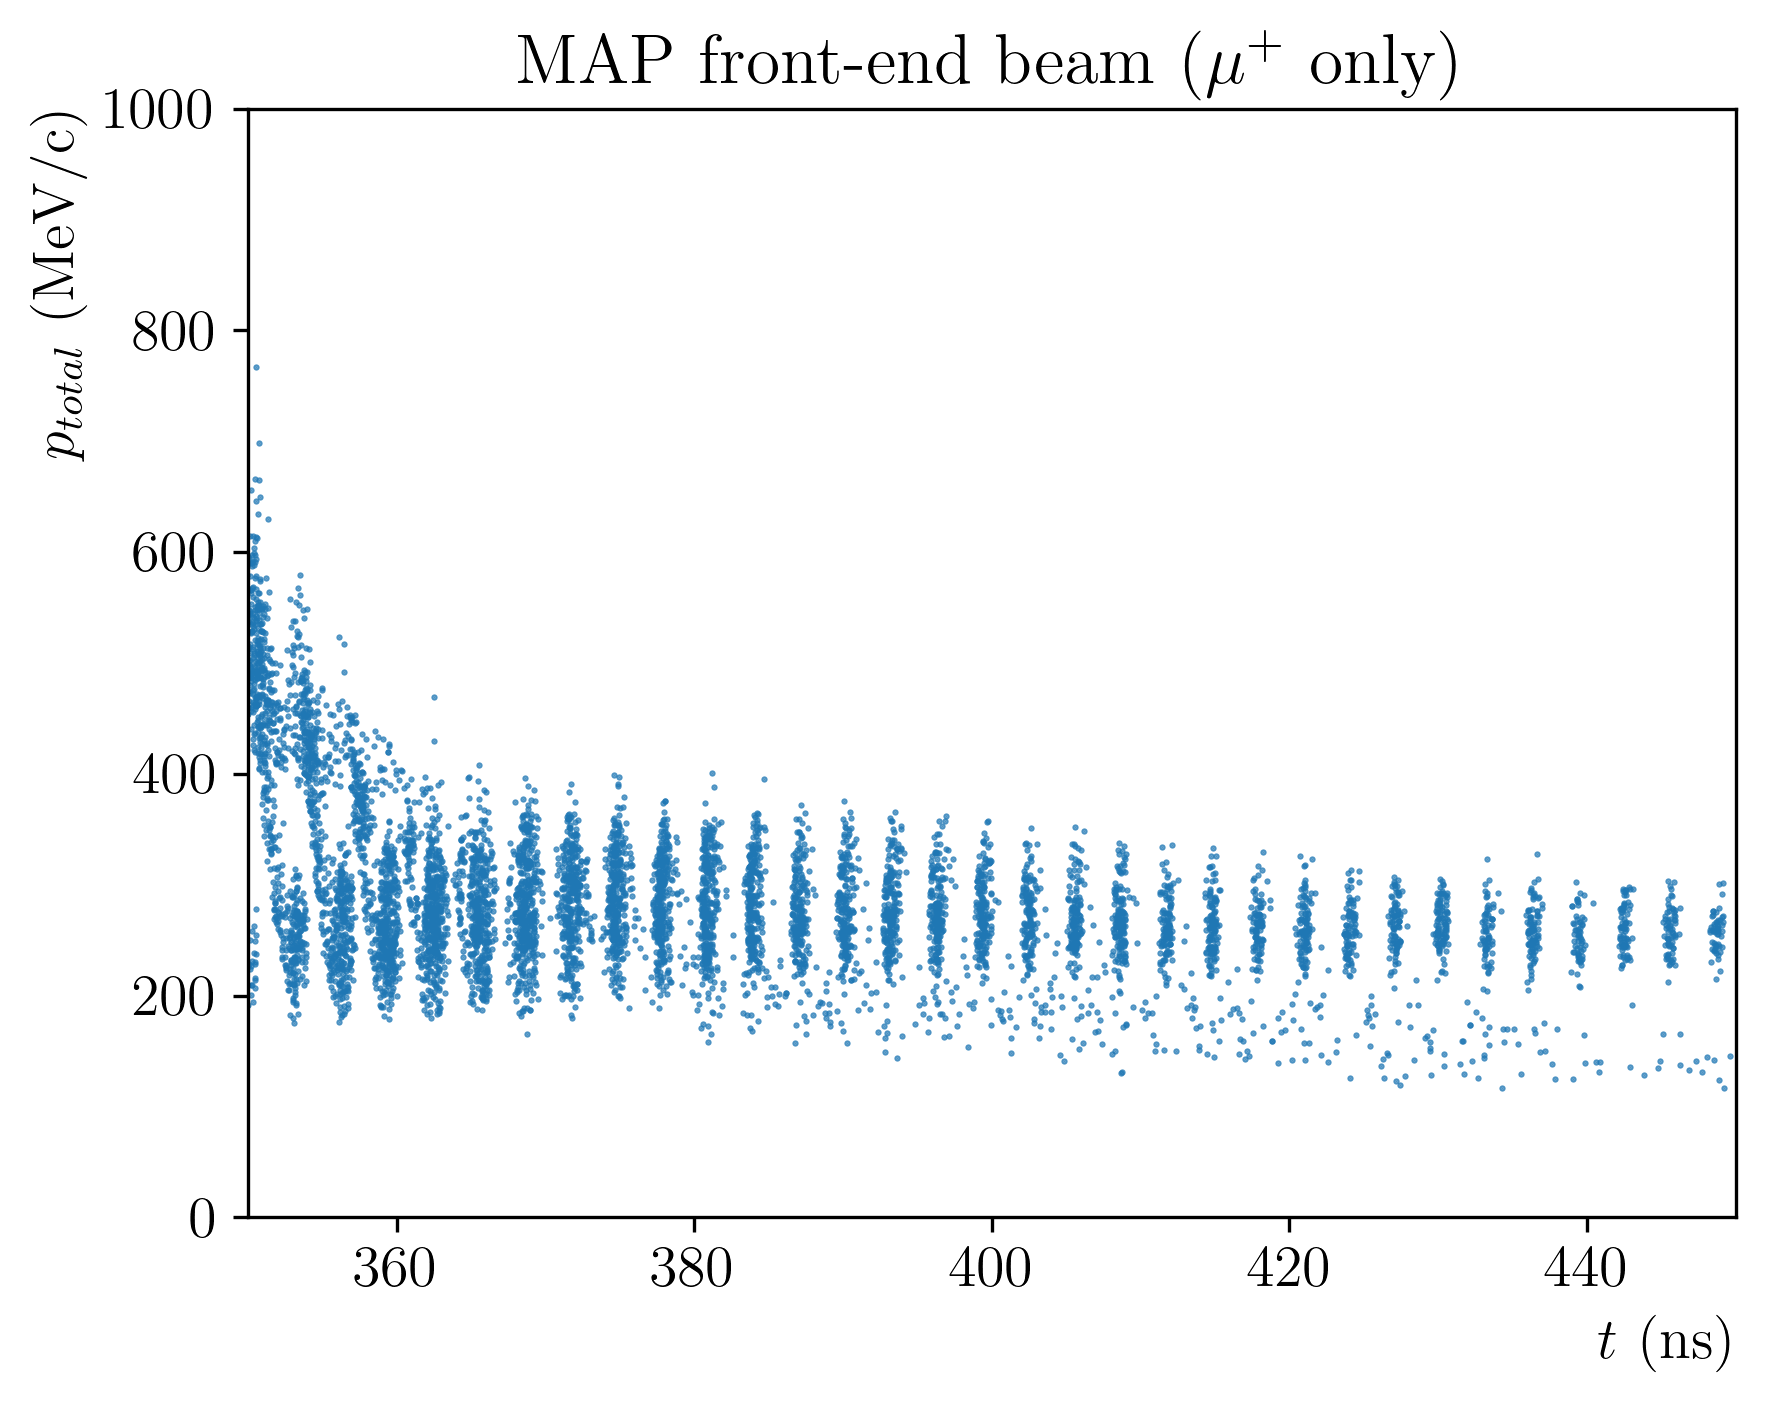

In [68]:
plt.scatter(timesmu, ptotalmu, alpha=0.8, s=0.25)
plt.xlabel('$t$ (ns)',loc='right')
plt.ylabel('$p_{total}$ (MeV/c)',loc='top')
plt.title('MAP front-end beam ($\mu^+$ only)')
plt.xlim(350,450)
plt.ylim(0,1000)
plt.show()

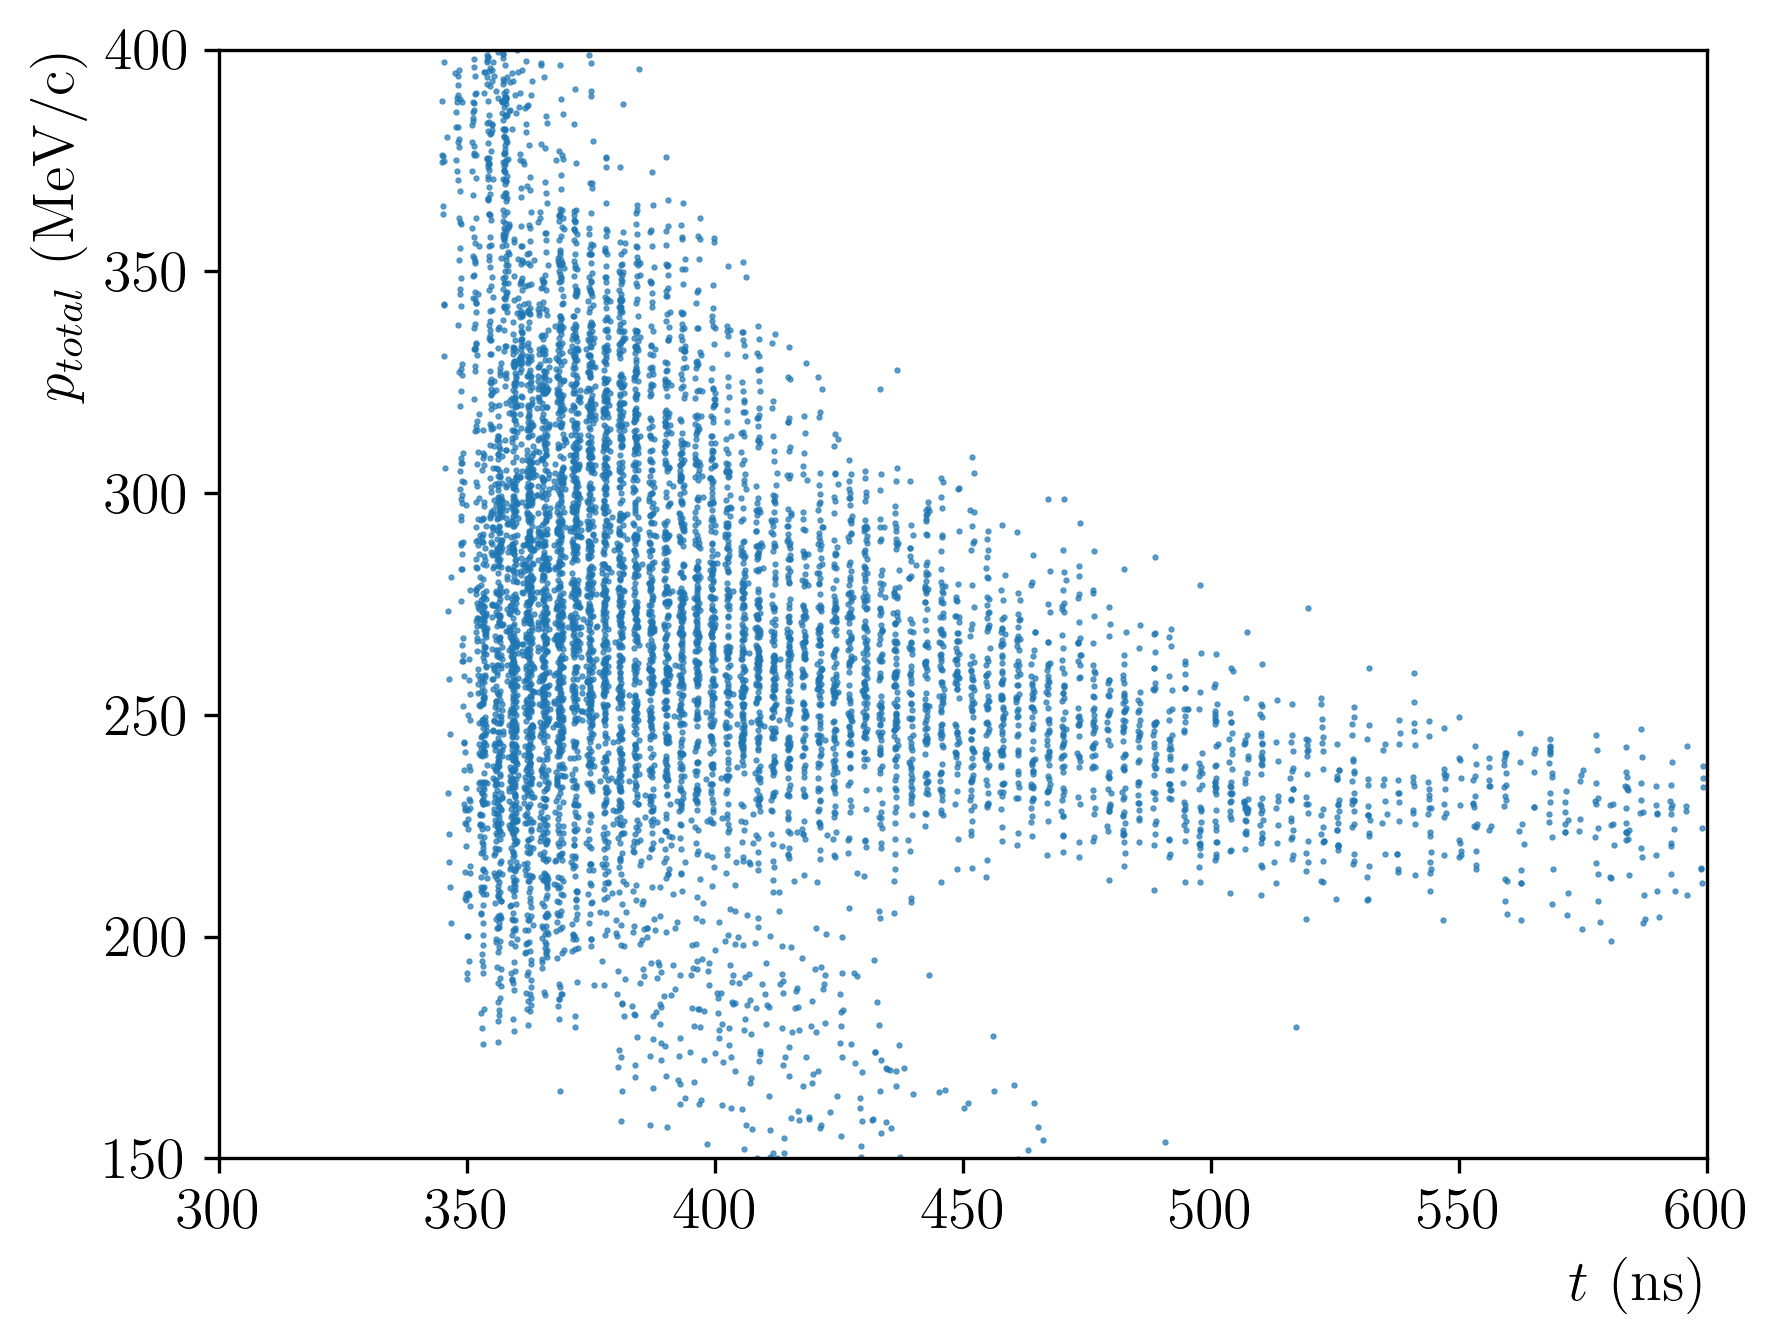

In [77]:
plt.scatter(timesmu, ptotalmu, alpha=0.8, s=0.25)
plt.xlabel('$t$ (ns)',loc='right')
plt.ylabel('$p_{total}$ (MeV/c)',loc='top')
plt.xlim(300,600)
plt.ylim(150,400)
plt.show()

In [73]:
1/(325e6)*10**9

3.076923076923077

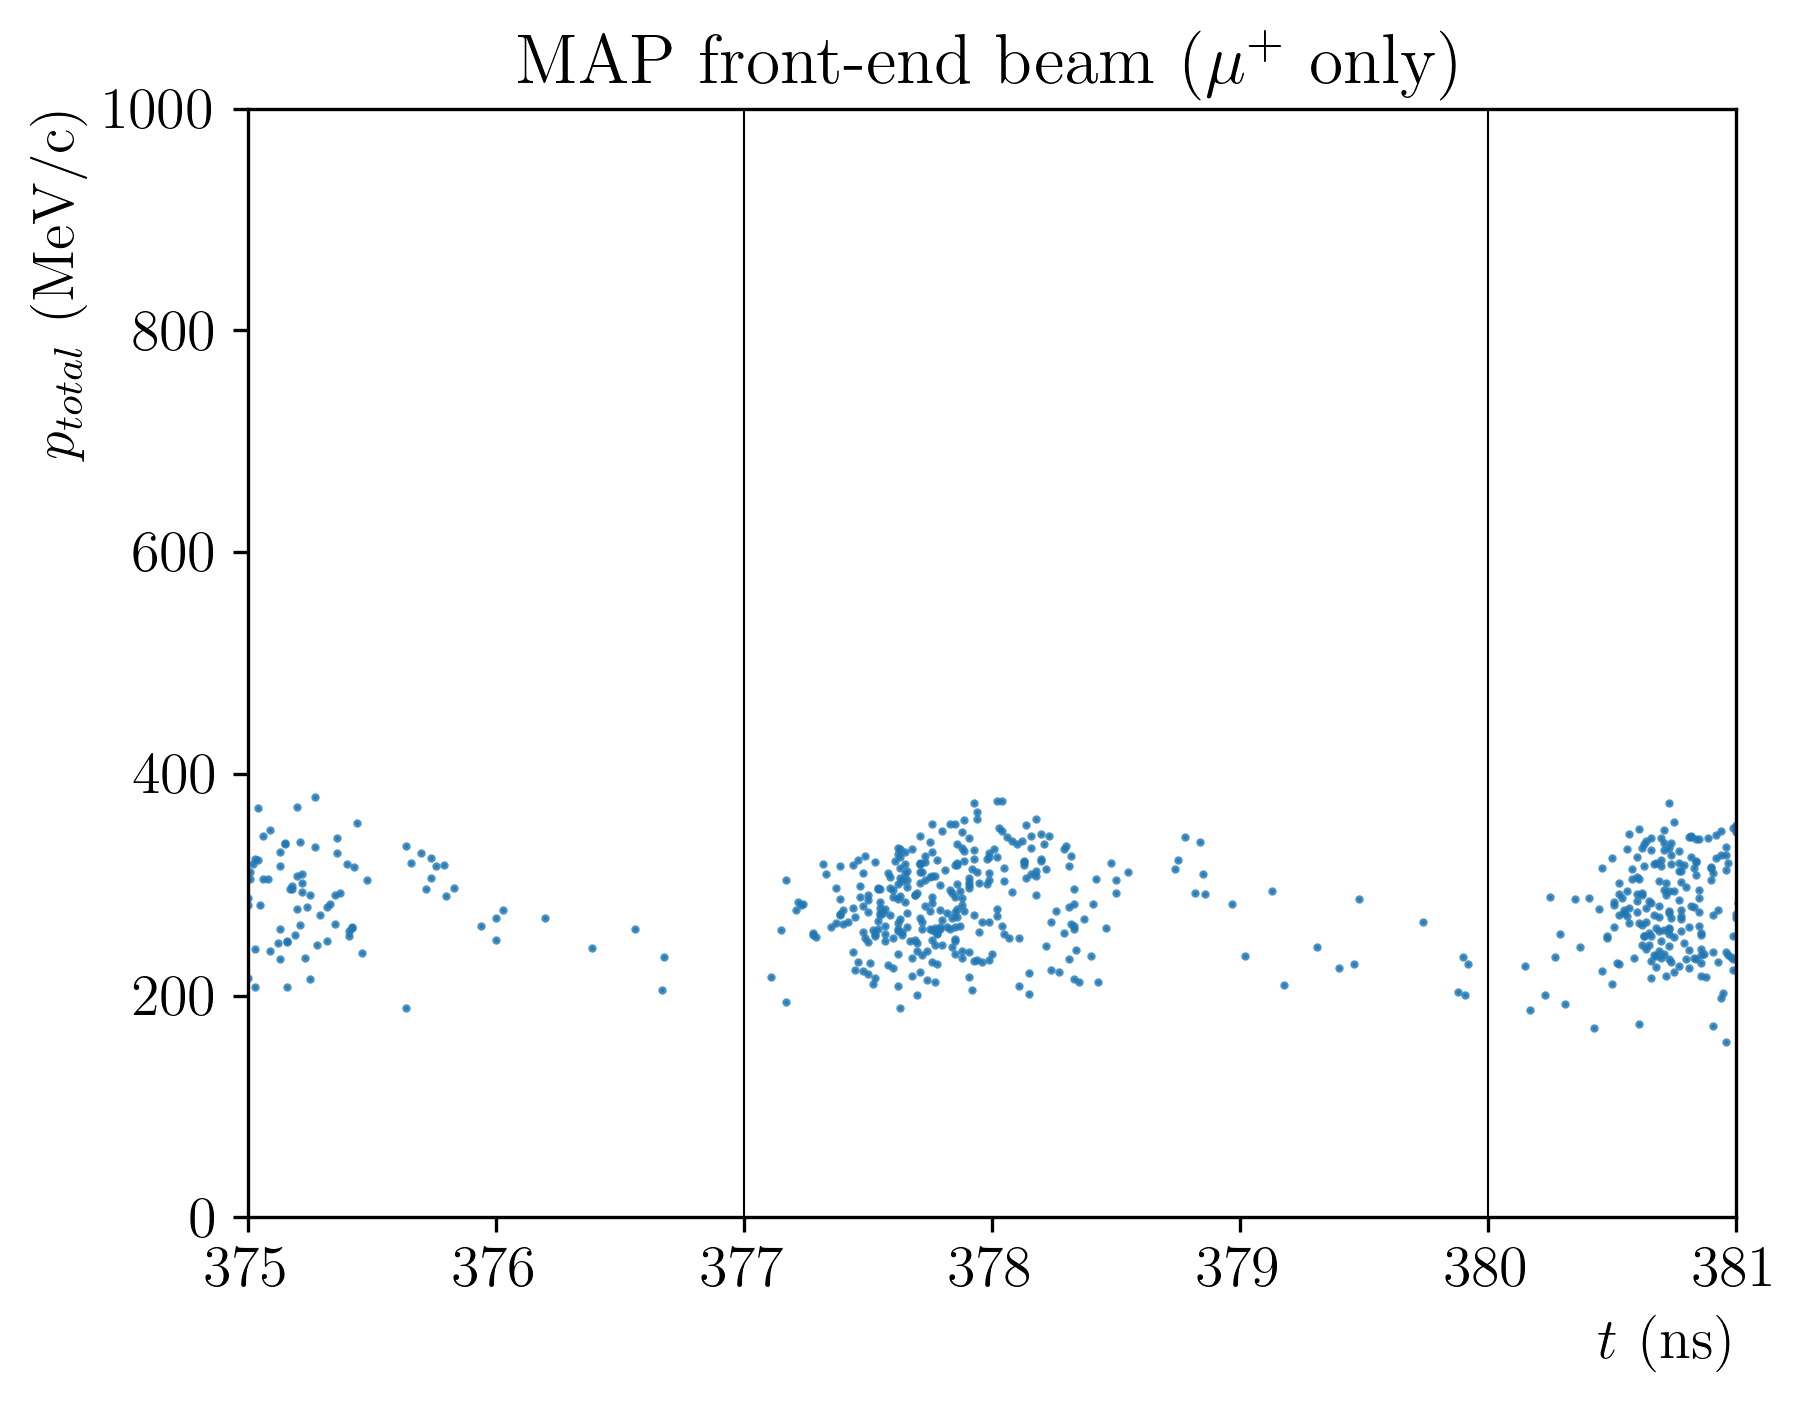

In [71]:
plt.scatter(timesmu, ptotalmu, alpha=0.8, s=1)
plt.xlabel('$t$ (ns)',loc='right')
plt.ylabel('$p_{total}$ (MeV/c)',loc='top')
plt.title('MAP front-end beam ($\mu^+$ only)')
plt.xlim(375,381)
plt.ylim(0,1000)
plt.axvline(377,lw=0.5,color='black')
plt.axvline(380,lw=0.5,color='black')
plt.show()

### More recent beam ($\mu^-$)

Provided by Diktys. Distribution should be consistent with Figure 3 of https://journals.aps.org/prab/abstract/10.1103/PhysRevSTAB.18.031003.

In [15]:
# Define input beam file:
file2 = 'for003Pre6D_g4bl.dat'

In [16]:
# Read in data from file:
df2 = pd.read_csv(file2, comment='#', sep=r'\s+', 
                 names=["x", "y", "z", "Px", "Py", "Pz", "t", "PDGid", "EventID", "TrackID", "ParentID", "Weight"])

ptotal2 = totalMomentum(df2)

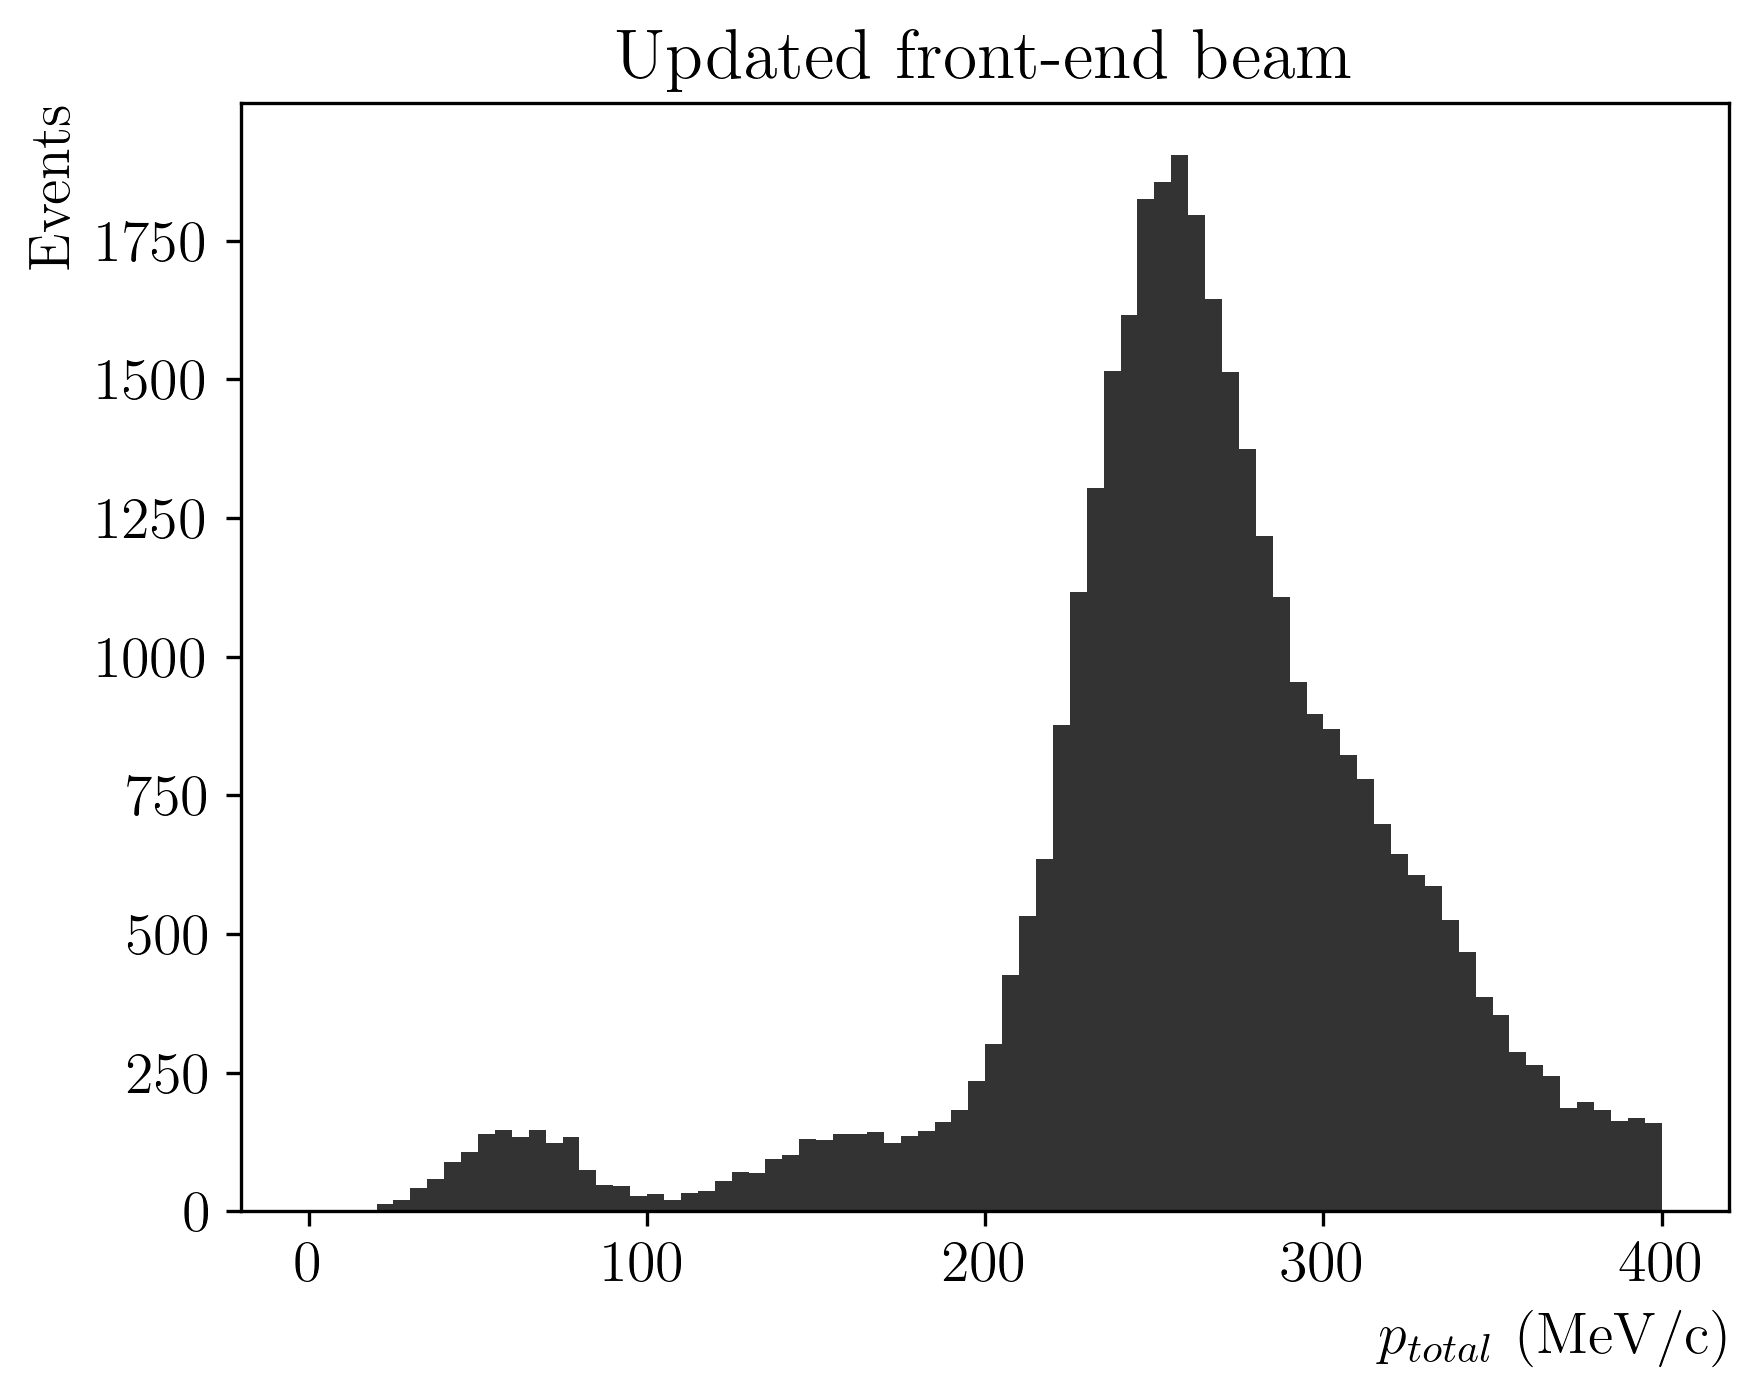

In [17]:
# Plot distribution:
plt.hist(ptotal2,bins=80,range=(0,400), color='black', alpha=0.8)
plt.xlabel('$p_{total}$ (MeV/c)',loc='right')
plt.ylabel('Events',loc='top')
plt.title('Updated front-end beam')
plt.show()

In [18]:
# Include only mu-:
dfmu2 = df2[df2.PDGid == 13]

ptotalmu2 = totalMomentum(dfmu2)

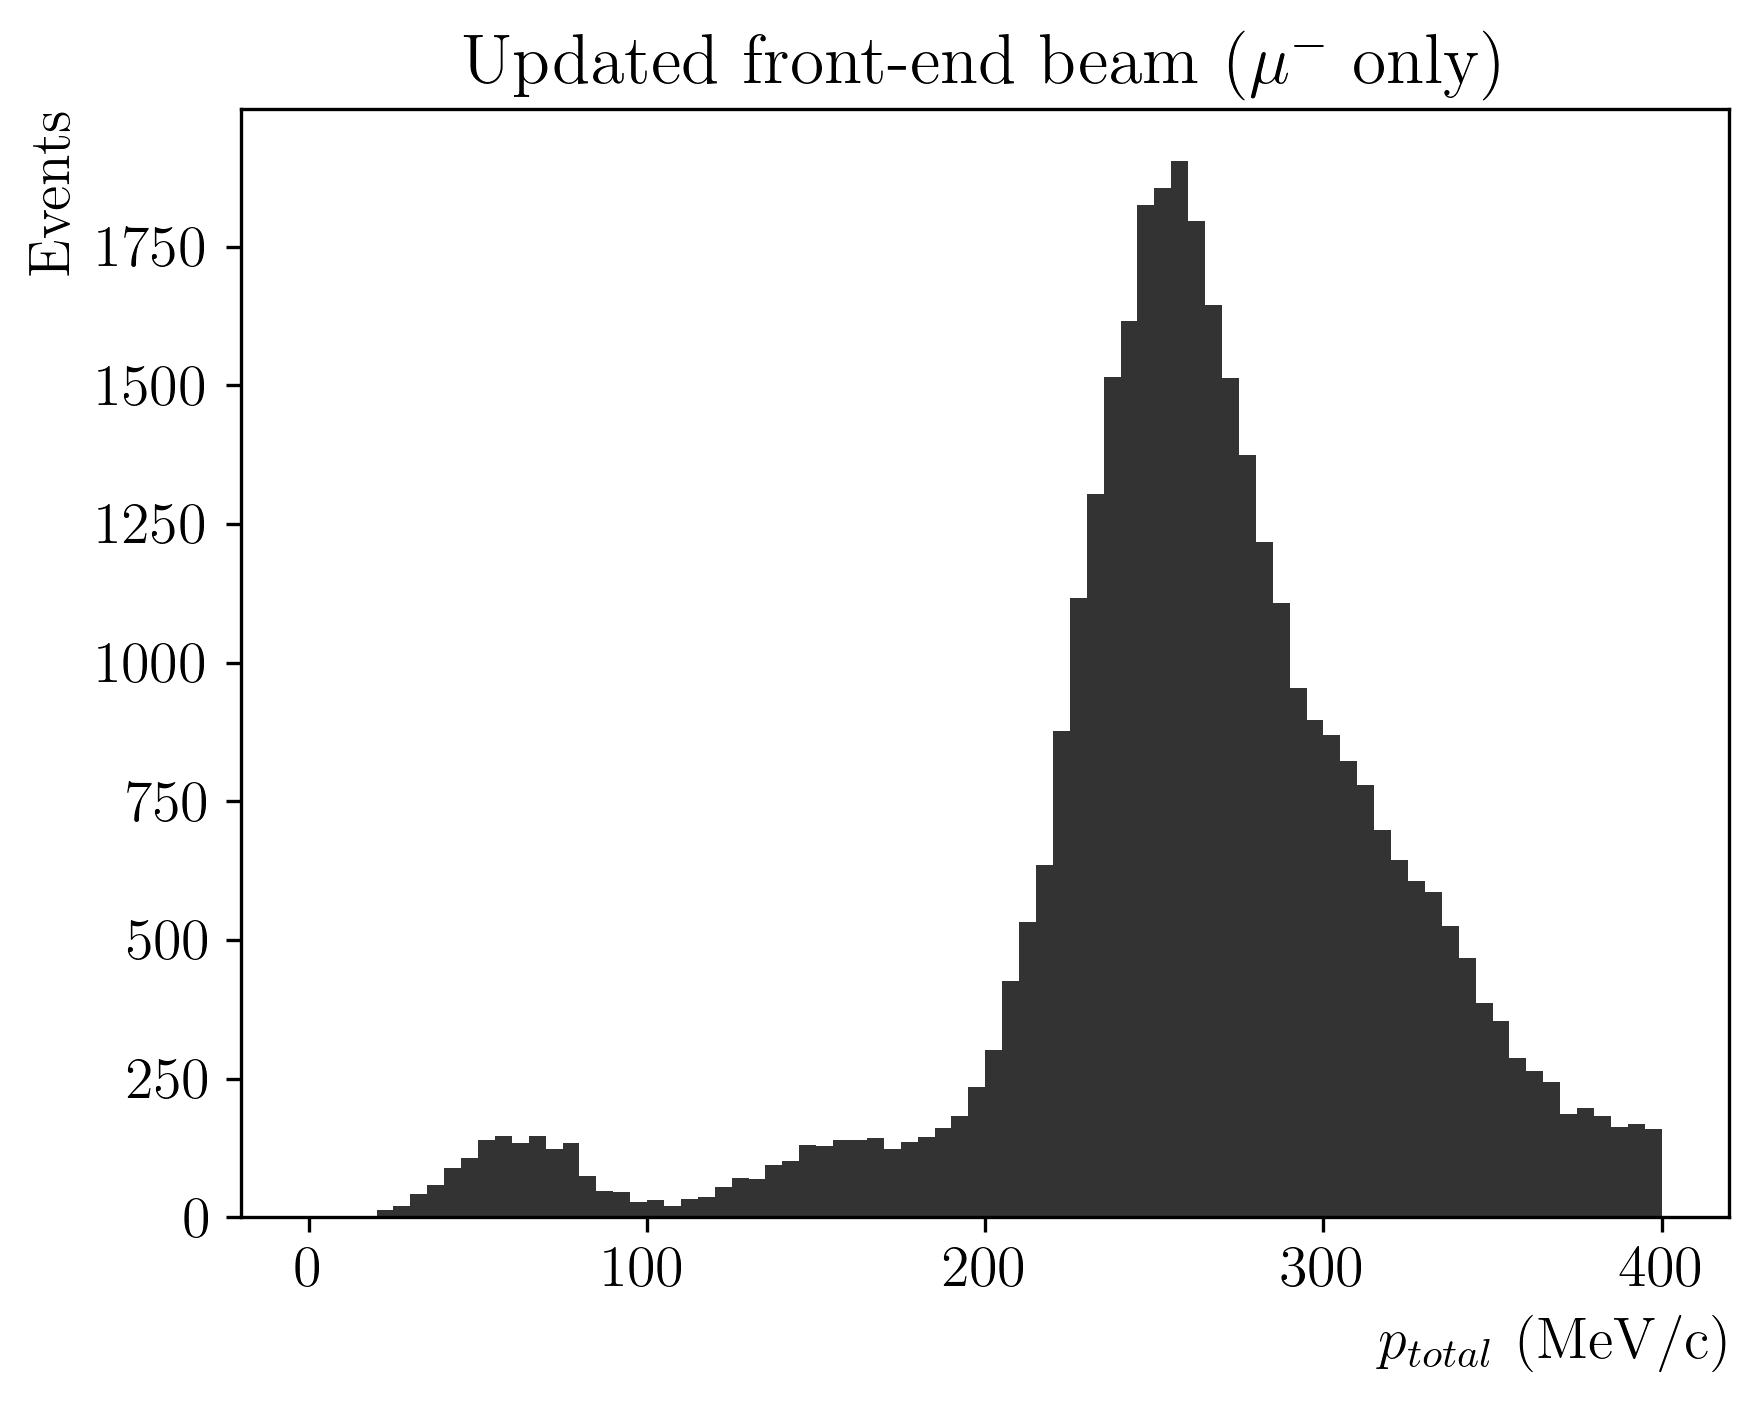

In [19]:
# Plot distribution:
plt.hist(ptotalmu2,bins=80,range=(0,400), color='black', alpha=0.8)
plt.xlabel('$p_{total}$ (MeV/c)',loc='right')
plt.ylabel('Events',loc='top')
plt.title('Updated front-end beam ($\mu^-$ only)')
plt.show()

In [20]:
# Number of mu-:
N2 = len(dfmu2)
print(N2)

46096
